# 1.3 Plotting Functions in Julia

In this notebook, I will introduce some of the common functions that will be used to test optimization algorithms that will be covered later on in the course.  There are many plotting packages in Julia such as

* Plots.jl
* Makie.jl
* PGFPlotsX.jl

In this course I will also show you how you can use the `CairoMakie`  (which is part of the  Makie.jl) plotting package to plot graphs.

First tell Julia that you will be using the `CairoMakie` plotting package

In [2]:
using CairoMakie

In many engineering problems, we will be required to find the minimum of a function.  Let's consider the quadratic function 
$f(x)=x^2-2x+0.6$ in the domain $x\in [0,2]$

In [3]:
f(x)=x^2-2x+0.6;

Define the domain to plot $x\in[0,2]$

In [4]:
xplot=0:0.01:2

0.0:0.01:2.0

Recall that the code above generates a range in Julia.  A range is an ordered sequence of value.  They do not really allocate memory to individual members unless they need to. To get range the generate individual members, you can use the command `Array(xplot)`

In [36]:
Array(xplot)

201-element Vector{Float64}:
 0.0
 0.01
 0.02
 0.03
 0.04
 0.05
 0.06
 0.07
 0.08
 0.09
 ⋮
 1.92
 1.93
 1.94
 1.95
 1.96
 1.97
 1.98
 1.99
 2.0

We will evaluate function `f` at every element of `xplot` so that we can plot the graph

In [5]:
f.(xplot)

201-element Vector{Float64}:
 0.6
 0.5801
 0.5604
 0.5408999999999999
 0.5216
 0.5025
 0.4836
 0.4649
 0.44639999999999996
 0.4281
 ⋮
 0.4464
 0.4649
 0.4835999999999999
 0.5024999999999998
 0.5215999999999997
 0.5409
 0.5603999999999999
 0.5801000000000002
 0.6

The code below plots the graph for $f(x)$

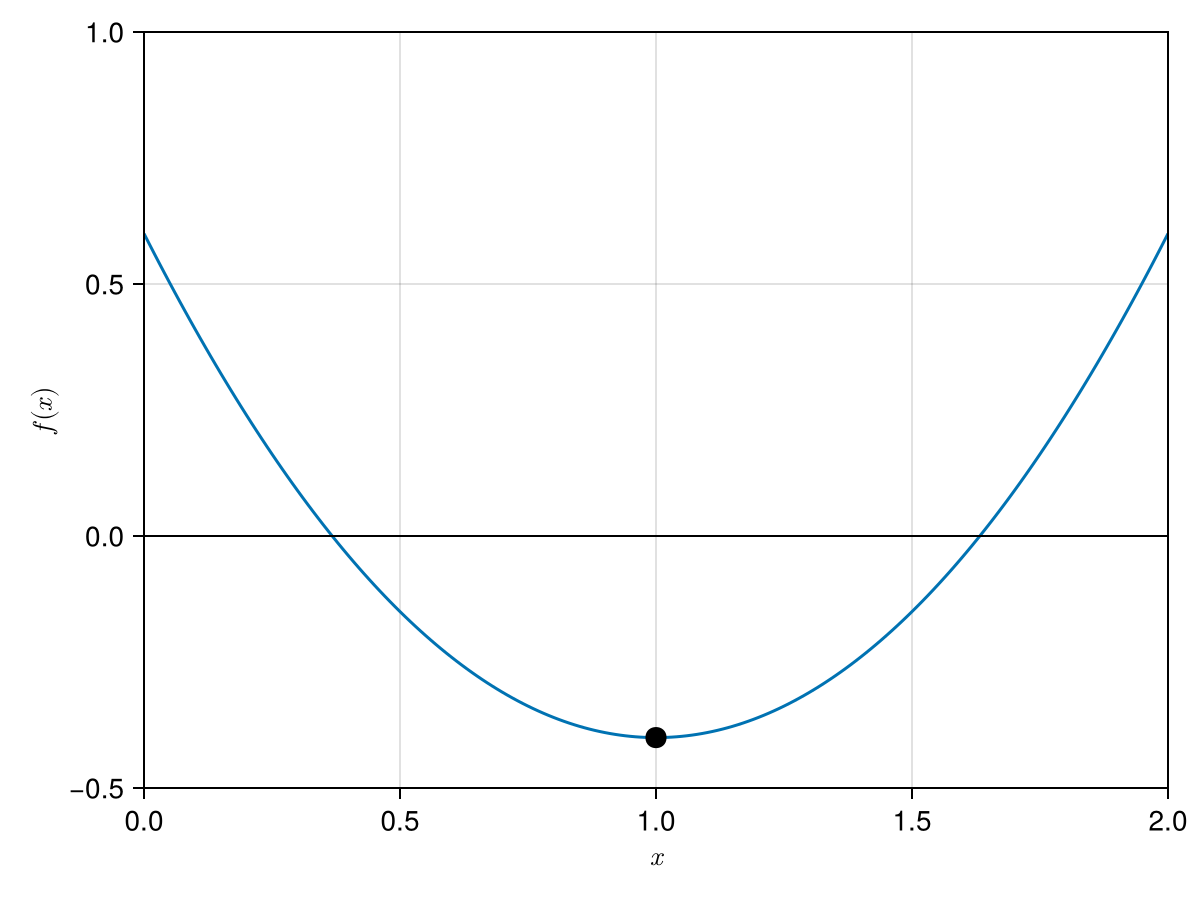

CairoMakie.Screen{IMAGE}


In [6]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",limits=(0,2,-0.5,1.0))
lines!(ax,xplot,f.(xplot)) #main code to plot f(x)
hlines!(ax,[0],color=:black,linewidth=1.0)
scatter!(ax,1,f.(1);color=:black,markersize=15)
save("../figures/01p03PlottingFunctionsInJulia01.svg", fig) #save figure as svg file
display(fig)

It is clear from the graph above that there is a local minimum at $x=1$, which is indicated by the black dot.

---
 We will now introduce a more complex function which we will use later on in the course

$f(x)=(x^3-x)^2$

<u>Exercise Ex01:</u>  Show that this function has a minimum at $x=0,\pm 1$ and maximum at $x=0,\pm 1/\sqrt{3}$ 


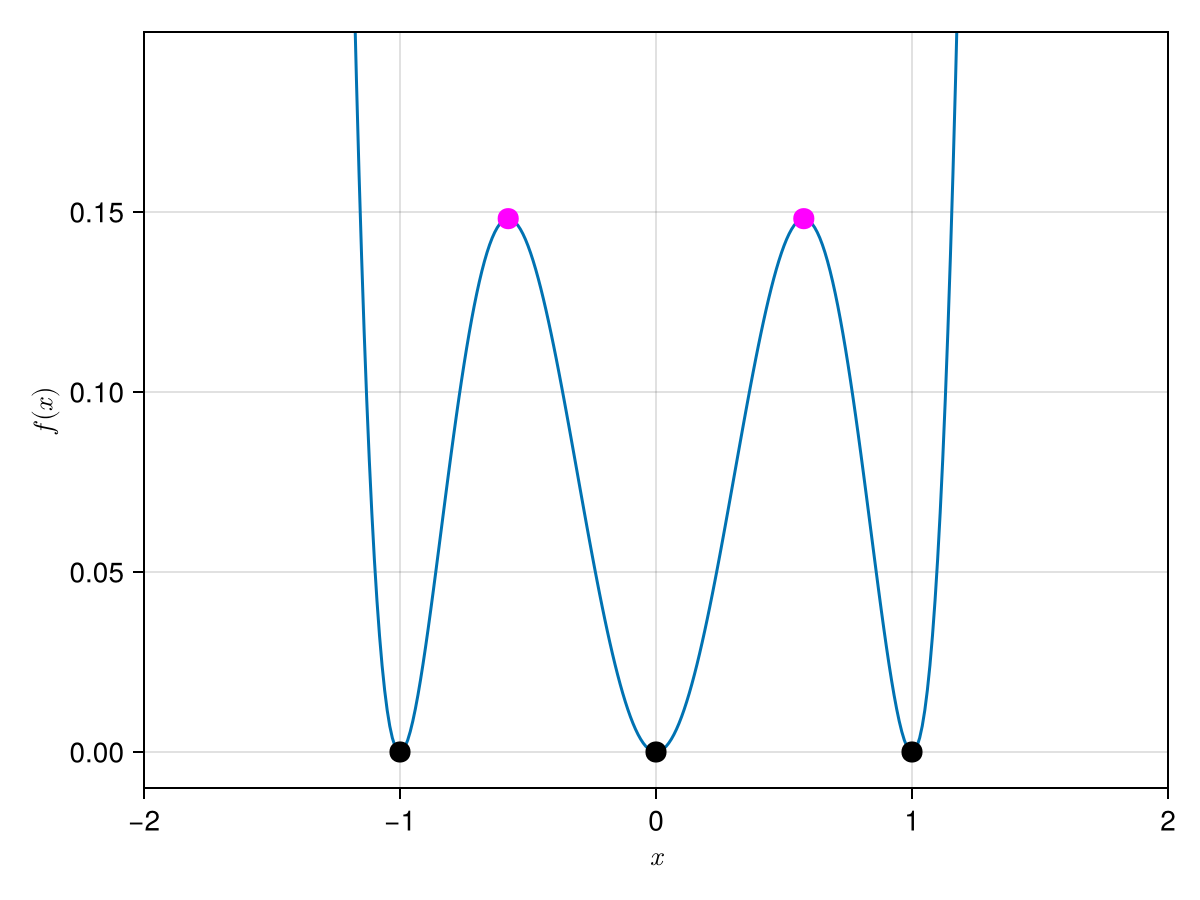

CairoMakie.Screen{IMAGE}


In [39]:
f(x)=(x^3-x)^2
xplot=-2.0:0.01:2.0
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",limits=(-2,2,-0.01,0.2))
lines!(ax,xplot,f.(xplot))
scatter!(ax,[0, -1, 1],f.([0, -1, 1]);color=:black,markersize=15)
scatter!(ax,[1/sqrt(3), -1/sqrt(3)],f.([1/sqrt(3), -1/sqrt(3)]);color=:magenta,markersize=15)
display(fig)

---
**Class Demo 01:** Write a Julia program to plot the function $A(r)=2\pi r^2+\frac{2}{r}$

---


Define the himmelblau function and plot it as a contour plot.  The himmelblau function below takes as an input the variable $x$.  In the example below, $x$ is a vector.  In my notes, I will sometimes denote vector with an arrowhead on top of the variable, $\vec{x}$.

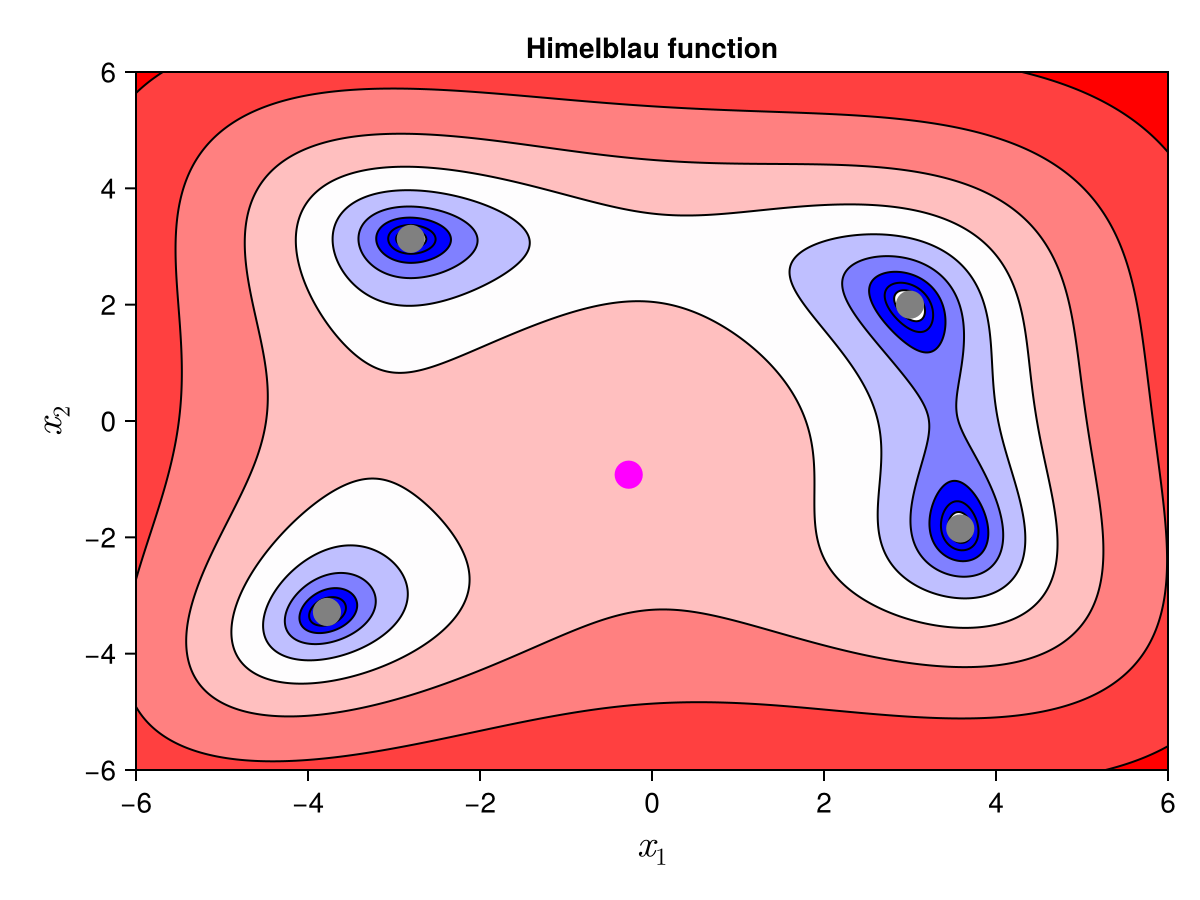

CairoMakie.Screen{IMAGE}


In [40]:
himmelblau(x)=(x[1]^2+x[2]-11)^2+(x[1]+x[2]^2-7)^2 #the input of himmelblau is x which is a vector of two elements.

x1range=-6:0.02:6;
x2range=-6:0.02:6;
funcplot = [himmelblau([x1,x2]) for x1 in x1range, x2 in x2range]

fig = Figure()
ax = Axis(fig[1, 1], 
    xlabel = L"x_1", 
    ylabel = L"x_2",
    xlabelsize = 20, 
    ylabelsize = 20,
    title = "Himelblau function",
    limits=(-6,6.0,-6.0,6.0))
levels = 10.0.^range(0, 3.5; length=10)
contourf!(ax,x1range,x2range,funcplot; levels,colormap=:bwr)
contour!(ax,x1range,x2range,funcplot; levels,label=true,color=:black)
save("../figures/01p03PlottingFunctionsInJulia02.svg", fig) #save figure as svg file

scatter!(ax,-0.270845,-0.923039;markersize=20,color=:magenta)
scatter!(ax,3.0,2.0,markersize=20,color=:grey)
scatter!(ax,-2.805118,3.13132,markersize=20,color=:grey)
scatter!(ax,-3.779310,-3.283136,markersize=20,color=:grey)
scatter!(ax,3.584428,-1.848126,markersize=20,color=:grey)


display(fig)

A few points to note

* There are 4 local minima in the himmelblau function shown above.


* There is one local maxima at 

    $(x_1,x_2)=(-0.270845...,-0.923039..)$ 

    and 4 local minima at 

    $(x_1,x_2)=(3.0,2.0)$\
    $ (-2.805118...,3.13132...)$\
    $(-3.779310...,-3.283136)$\
    $(3.584428,-1.848126..)$.  

* We will look at algorithms that can be used to find these 4 points.  Sometimes, the algorithms can also converge to the local maximum.


---
# Rosenbrock function


Another common function to test optimization algorithm is the Rosenbrock function

$f(x_1,x_2,p_1,p_2)=(p_1-x_1)^2+p_2(x_2-x_1^2)^2$

<u>Exercise Ex02:</u> Show that the Rosenbrock function has a local minimum  at $(x_1,x_2)=(p_1,p_1^2)$.

For simplicity, we will use the value $p_1=1$ and $p_2=1$.  For these values of $p_1$ and $p_2$, $f(x_1,x_2)$ will have a local minimum at $(x_1,x_2)=(1,1)$.  Let's plot the Rosenbrock function and see how it looks like

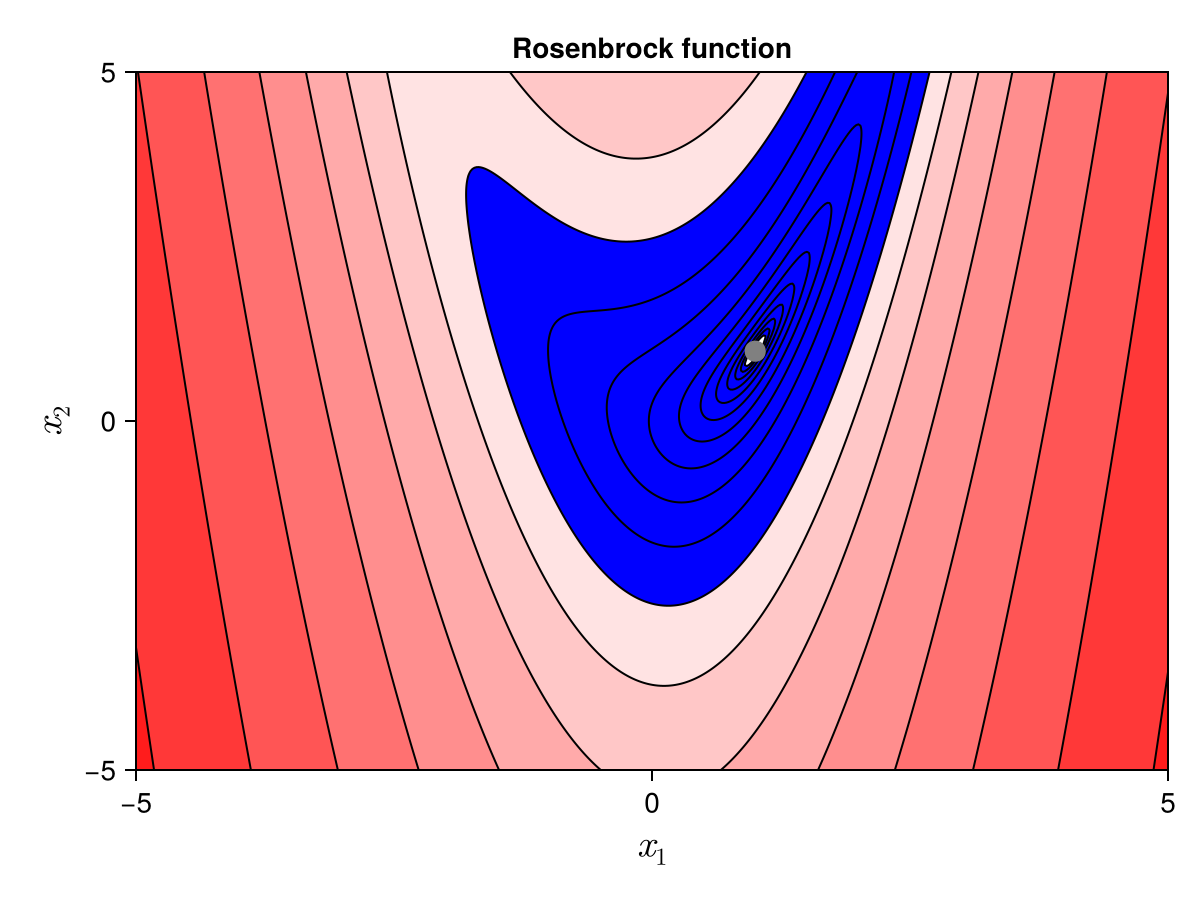

CairoMakie.Screen{IMAGE}


In [41]:
x1range=-5:0.02:5;
x2range=-5:0.02:5;

rosenbrock(x)=(1.0 - x[1])^2 + 1.0 * (x[2] - x[1]^2)^2
funcplot = [rosenbrock([x1,x2]) for x1 in x1range, x2 in x2range]

fig = Figure()
ax = Axis(fig[1, 1], 
    xlabel = L"x_1", 
    ylabel = L"x_2",
    xlabelsize = 20, 
    ylabelsize = 20,
    title = "Rosenbrock function",limits=(-5,5.0,-5.0,5.0))
levels = 10.0.^range(-2, 3.5; length=20)
contourf!(ax,x1range,x2range,funcplot; levels, colormap=:bwr)
contour!(ax,x1range,x2range,funcplot;  levels, color=:black)
scatter!(ax,[1],[1];color=:grey,markersize=15)
display(fig)

* The  local minimum, $(x_1,x_2)=(1,1)$, is located at a long narrow valley which makes finding this minimum very challenging.  

<u>Exercise Ex03:</u> Plot the Rosenbrock function for different values of $p_1$ and $p_2$ and comment on how the function changes.

---

**Class Demo 02:**. Write a Julia program to do a contour plot of the function 

$f(\vec{x})=\sin(x_1)\cos(3x_2)$

---

Prepared Andrew Ooi 7th July 2026